In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ecommerce_customer_behavior_dataset_v2.csv')

df['Date'] = pd.to_datetime(df['Date'])

df['Age_Group'] = pd.cut(df['Age'],
                        bins=[18, 25, 35, 45, 55, 65, 76],
                        labels=['18-24', '25-34', '35-44', '45-54', '55-64', '65-75'] 
                         )

df['Discount_Status'] = np.where(df['Discount_Amount'] > 0, 'Discount Applied', 'No Discount')


## ANALİZ HİSSƏSİ

---

### Ön analiz bölümləri

* Müştəri davranışı

* Demoqrafik dəyərlər

* Digər dəyərlər

### Müştəri profili analizi

---

### Ön analiz bölümü

Bu bölümdə müxtəlif dəyişənlərlə satış dəyərləri arasındaki əlaqəni analiz edərkən, ikinci hissədə müştəri profili yaratmaq üçün bu dəyişənləri necə istifadə edəcəyimizi müəyyən edəciyik. Qısacası müştəri davranışlarını ayrılıqda tanıyıb müştəri profili yaratmaq üçün istifadə edəciyik.

---

* Müştəri davranışı
Returning Customer - Returning customers yeni müştərilərlə müqayisədə daha çox xərcləyirlərmi?

Bu sütunu Total_Amount, Quantity, Pages_Viewed və Session_Duration_Minutes ilə müqayisə etmək xüsusilə maraqlı ola bilər.

İlk əvvəl bizim bu data setdə nə qədər müştərimiz var onu öyrənən.

In [3]:
df['Customer_ID'].nunique()

5000

In [4]:
customer_status_2 = df.groupby("Customer_ID")["Is_Returning_Customer"].sum()

only_false_customers = customer_status_2[customer_status_2 == 0]

print(only_false_customers)
print("Yalnız False olan müştərilərin sayı:", len(only_false_customers))

Customer_ID
CUST_00004    0
CUST_00009    0
CUST_00012    0
CUST_00037    0
CUST_00081    0
             ..
CUST_04966    0
CUST_04987    0
CUST_04988    0
CUST_04998    0
CUST_04999    0
Name: Is_Returning_Customer, Length: 349, dtype: int64
Yalnız False olan müştərilərin sayı: 349


In [5]:
customer_status_2 = df.groupby("Customer_ID")["Is_Returning_Customer"].agg(["any", "all"])

only_false = customer_status_2[
    (customer_status_2["any"] == False)
]

false_to_true = customer_status_2[
    (customer_status_2["any"] == True) &
    (customer_status_2["all"] == False)
]

only_true = customer_status_2[
    (customer_status_2["all"] == True)
]

any_true = customer_status_2[
    (customer_status_2['any'] == True)
]

print("Yalnız False olanlar:", len(only_false))
print("False → True olanlar:", len(false_to_true))
print("Yalnız True olanlar:", len(only_true))
print("True olanlar:", len(any_true))

Yalnız False olanlar: 349
False → True olanlar: 1661
Yalnız True olanlar: 2990
True olanlar: 4651


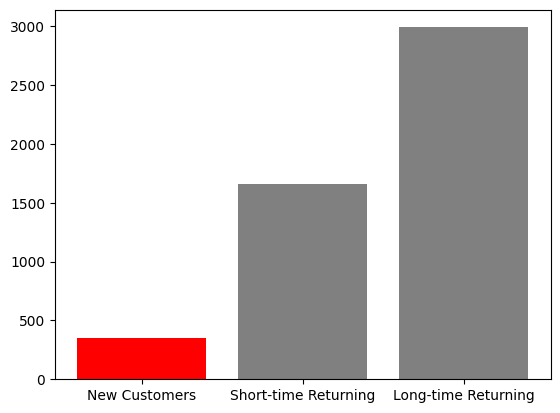

In [6]:
cust_categories = [
    'New Customers',
    'Short-time Returning',
    'Long-time Returning'
]

cus_counts = [
    len(only_false),
    len(false_to_true),
    len(only_true)
]

plt.bar(cust_categories, cus_counts, color=['red', 'grey', 'grey'])

plt.show()

Dataya görə müştəri sayımız 5000-dir.

İs_returning_customer sütununu analiz etmək üçün müştəriləri həm 2 qrupa həmdə 3 qrupa olacaq şəkildə ayırdıq.

1. 2-li qruplaşdırma: 
*yeni müştərilər - 349 
*qayıdan müştərilər - 4651

2. 3-lü qruplaşdırma: 
*yeni müştərilər - 349
*qısa-zaman qayıdan müş - 1661
*uzun-zaman qayıdan müş - 2990

Bu iki qruplanmanı ayrılıqda analiz etməyə çalışaq.

In [7]:
false_customers = only_false.index
true_customers = any_true.index

false_group = df[df["Customer_ID"].isin(false_customers)]
true_group = df[df["Customer_ID"].isin(true_customers)]

false_aov = false_group.groupby("Order_ID")["Total_Amount"].sum().mean()
true_aov = true_group.groupby("Order_ID")["Total_Amount"].sum().mean()

print("Yalnız False olanların AOV:", false_aov)
print("True olanların AOV:", true_aov)

Yalnız False olanların AOV: 1148.3400859598853
True olanların AOV: 1280.1366407185628


Ən azı bir dəfə returning statusunda olan müştərilərin sifarişləri, yalnız new customer kimi qalan müştərilərin sifarişlərindən orta hesabla 11.5% daha yüksək dəyərlidir.

---

Sual:

Geri qayıdan müştərilər endirimlərdən daha çox istifadə edir? (endrimi rate)

Geri qayıdan müştərilərin Customer_reting -ləri daha yüksəkdir?

In [8]:
false_discount_rate = (false_group["Discount_Amount"] > 0).mean() * 100

true_discount_rate = (true_group["Discount_Amount"] > 0).mean() * 100

print("Yalnız False olanların endirim istifadə faizi:", false_discount_rate)
print("True olanların endirim istifadə faizi:", true_discount_rate)

Yalnız False olanların endirim istifadə faizi: 33.2378223495702
True olanların endirim istifadə faizi: 38.08982035928143


In [435]:
false_avg_discount = (
    false_group[false_group["Discount_Amount"] > 0]["Discount_Amount"].mean()
)

true_avg_discount = (
    true_group[true_group["Discount_Amount"] > 0]["Discount_Amount"].mean()
)

print("Yalnız False olanların orta endirim məbləği:", false_avg_discount)
print("True olanların orta endirim məbləği:", true_avg_discount)

Yalnız False olanların orta endirim məbləği: 148.43413793103448
True olanların orta endirim məbləği: 184.34201540638264


Yuxarıdaki analizlərə əsasən müşahidə edə bilərki ki, geri qayıdan müştərilər yeni müştərilərə nisbətən endirimlərdən daha çox istifadə edir.

---

İkinci suala keçəy. "Geri qayıdan müştərilərin Customer_reting -ləri daha yüksəkdir?" sualına cavab tapaq. Bu bizə həmdə müştərilərin niyə geri qayıtdığınıda göstərə bilər. Burda analizin daha dəqiq olması üçün geri qayıdan müştərilərin qısa-zaman içində olanlarını seçəciyiy. 

Bu sualı birazda düzəldəy: “Sonradan geri qayıdan müştərilərin ilk alış zamanı verdiyi rating, heç vaxt geri qayıtmayan yeni müştərilərin ratingindən daha yüksəkdirmi?”

In [9]:
false_to_true_customers = false_to_true.index

false_to_true_group = df[df['Customer_ID'].isin(false_to_true_customers)]

false_cust_rate = false_group['Customer_Rating'].mean()

false_to_true_cust_rate = false_to_true_group[false_to_true_group['Is_Returning_Customer'] == False]['Customer_Rating'].mean()

print('Yeni müştəri ratingləri', false_cust_rate)
print('Qısa zaman qayıdan müştəri ratingləri', false_to_true_cust_rate)

Yeni müştəri ratingləri 3.945558739255014
Qısa zaman qayıdan müştəri ratingləri 3.863335340156532


Bu nəticəyə əsasən geri qayıdan müştərilətin geri qayıtma səbəbləri kimi customer_rating ilə mənalı bir əlaqəsi yoxdur.

---

* Customer Rating ilə Deliver time arasında anlamlı bir əlaqə varmı?

Altsual: Discount Amount artdıqca Customer rating artırmı?

<Axes: xlabel='Delivery_Time_Days'>

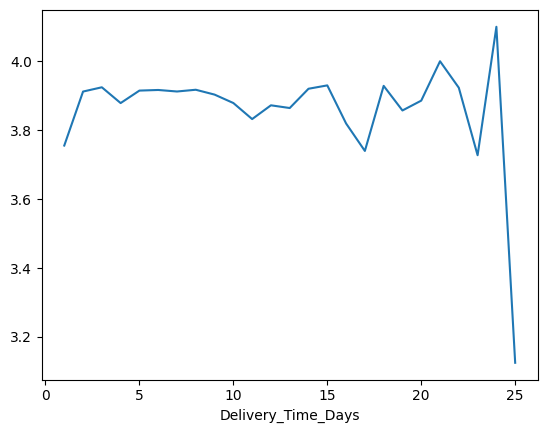

In [10]:
df.groupby('Delivery_Time_Days')['Customer_Rating'].mean().plot(kind='line')

In [11]:
df['Delivery_Time_Days'].corr(df['Customer_Rating'])

np.float64(-0.008479800150828385)

Burda da mənalı bir əlaqə və analiz nəticəsi çıxmadı. Sifarişin sürətli gəlməyi onun ratingini artırmır.

Delivery_times sütununa demografik dəyərr analizində yenidən baxılacaq.

---

* Müştəri davranışlarını analizə davam edək. Bu dəfə insanların Pages_viewed dəyərlərini anlamaq üçün müxtəlif analizlər edək.

In [12]:
df.groupby('Pages_Viewed')['Discount_Amount'].count()

Pages_Viewed
1       12
2       19
3      100
4      267
5      618
6     1249
7     2010
8     2702
9     2975
10    2806
11    2036
12    1243
13     658
14     234
15      97
16      18
17       4
18       1
Name: Discount_Amount, dtype: int64

In [13]:
df.groupby('Pages_Viewed')['Total_Amount'].sum()

Pages_Viewed
1       14957.87
2       34565.19
3      134307.35
4      295159.63
5      766044.44
6     1542886.16
7     2540007.68
8     3545721.08
9     3665784.04
10    3638603.69
11    2607321.97
12    1582108.52
13     994690.88
14     293655.05
15      87126.71
16      24825.20
17      10978.58
18        308.55
Name: Total_Amount, dtype: float64

In [14]:
df['Pages_Viewed'].describe()

count    17049.000000
mean         9.003109
std          2.259954
min          1.000000
25%          7.000000
50%          9.000000
75%         11.000000
max         18.000000
Name: Pages_Viewed, dtype: float64

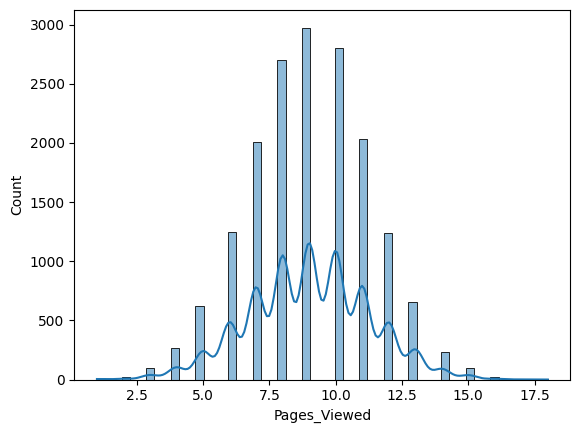

In [15]:
sns.histplot(df['Pages_Viewed'], kde=True)

plt.show()


---


In [16]:
pages_frequency = df["Pages_Viewed"].value_counts().sort_index()

print(pages_frequency)

Pages_Viewed
1       12
2       19
3      100
4      267
5      618
6     1249
7     2010
8     2702
9     2975
10    2806
11    2036
12    1243
13     658
14     234
15      97
16      18
17       4
18       1
Name: count, dtype: int64


In [17]:
print("Mean:", df["Pages_Viewed"].mean())
print("Median:", df["Pages_Viewed"].median())
print("Mode:", df["Pages_Viewed"].mode()[0])

Mean: 9.003108686726494
Median: 9.0
Mode: 9



---


Dəyərlərin ehtimal paylanmasını yoxlayaq

Sənin nəticələrində çox diqqətçəkən bir şey var:

* Minimum = 1
* Maksimum = 18
* Bütün 1–18 dəyərləri mövcuddur
* Mean ≈ Median = Mode = 9
* Skewness ≈ 0
* Kurtosis ≈ 0

Paylanma çox səliqəli, simmetrik zəng formasındadır

Bu, süni şəkildə normal paylanmadan sample götürülmüş dəyişənə bənzəyə bilər. Bu səbəblə bu dəyişəni analiz zamanı diqqətə almayacayıq. 

Eyni problem Session_Duration_Minutes sütununda da müşahidə olunur.

---

Müştəri davranış analizini burda saxlayaq.

---

### Demoqrafik dəyərlər

* Müştərilərin olduğu şəhərlərin Deliver_Time_Days ilə qruplaşdırma analizləri.

In [18]:
df.groupby('City')['Delivery_Time_Days'].mean()

City
Adana        6.309201
Ankara       6.557391
Antalya      6.529695
Bursa        6.503777
Eskisehir    6.307365
Gaziantep    6.449704
Istanbul     6.511586
Izmir        6.527027
Kayseri      6.609871
Konya        6.613393
Name: Delivery_Time_Days, dtype: float64

In [19]:
df['Delivery_Time_Days'].mean()

np.float64(6.503607249692064)

Delivery_Time_Days sütunu kateqoriya olaraq logistika elementi sayılır, lakin bizə biznes tərəfi üçün maraqlı bir insight verə bilər.

Bu baxımdan City sütunu ilə Delivery_Time_Days dəyişkənini grup analizi etdik. Ama gözlədiyimin əksinə şəhərlər arasında çatdırılma vaxtlarında fərq yoxdu. ((Burda sadəcə dataya baxıb şirkətin logistika sxemini görmüş oluruq.))  


---

* Növbəti olaraq isə digər demoqrafik dəyərlər olan Yaş və Cinsiyət sütunlarını analiz edib araşdıraq.

In [20]:
gender_analysis = df.groupby('Gender').agg(
    order_n=('Order_ID', 'count'),
    total_a=('Total_Amount', 'sum'),
    avrg_a=('Total_Amount', 'mean')
)

gender_analysis

,order_n,total_a,avrg_a
Gender,,,
Female,8613,11037984.60,1281.549356
Male,8176,10343185.70,1265.066744
Other,260,397882.29,1530.316500


Cinslərə görə kişilər və qadınlar arasında satış performansı yaxındır. 

In [21]:
category_gender = df.groupby(['Product_Category', 'Gender']).agg(
    order_nu=('Order_ID', 'count'),
    total_am=('Total_Amount', 'sum'),
    avrg_am=('Total_Amount', 'mean')
)

category_gender

order_nu    total_am      avrg_am
Product_Category Gender                                   
Beauty           Female      1102   341442.59   309.839011
                 Male        1083   344659.47   318.245125
                 Other         27     8334.96   308.702222
Books            Female      1103   180434.35   163.585086
                 Male        1062   173074.11   162.969972
                 Other         41     6890.65   168.064634
Electronics      Female      1034  5214505.51  5043.042079
                 Male        1008  5053938.23  5013.827609
                 Other         32   213453.91  6670.434688
Fashion          Female      1039   811866.59   781.392291
                 Male         983   744393.82   757.267365
                 Other         34    20775.29   611.037941
Food             Female      1078   217725.97   201.972143
                 Male        1002   198846.13   198.449232
                 Other         23     5482.55   238.371739
Home & Garden    Female      1064  2091887.73  1966.059897
                 Male         967  1872271.91  1936.165367
                 Other         29    59744.30  2060.148276
Sports           Female      1134  1644781.57  1450.424665
                 Male        1069  1492620.41  1396.277278
                 Other         45    67685.01  1504.111333
Toys             Female      1059   535340.29   505.514910
                 Male        1002   463381.62   462.456707
                 Other         29    15515.62   535.021379

Tabloya görə qadınlar hər üç sütunda da üstünlük təşkil edir. Amma üstünlük böyük fərq yaratmır.

Eyni tabloyu yaş qrupları üçün edək.

In [22]:
agegroup_gender = df.groupby(['Age_Group', 'Gender']).agg(
    order_nu=('Order_ID', 'count'),
    total_am=('Total_Amount', 'sum'),
    avrg_am=('Total_Amount', 'mean')
)

agegroup_gender

C:\Users\user\AppData\Local\Temp\ipykernel_7416\781334808.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agegroup_gender = df.groupby(['Age_Group', 'Gender']).agg(


order_nu    total_am      avrg_am
Age_Group Gender                                   
18-24     Female      1111  1543325.51  1389.131872
          Male        1098  1325373.64  1207.079818
          Other         27    15382.43   569.719630
25-34     Female      2538  3096972.68  1220.241403
          Male        2547  3338467.35  1310.744935
          Other         98   187569.04  1913.969796
35-44     Female      2499  3371782.04  1349.252517
          Male        2439  2986384.58  1224.429922
          Other         59    73503.41  1245.820508
45-54     Female      1198  1484918.98  1239.498314
          Male        1171  1479119.56  1263.125158
          Other         33    46587.97  1411.756667
55-64     Female       319   386491.24  1211.571285
          Male         231   248843.88  1077.246234
          Other          3     1182.35   394.116667
65-75     Female        35    44868.81  1281.966000
          Male          38    63342.64  1666.911579
          Other          0        0.00          NaN

Bu iki tablo bizə müxtəlif kriterialarda üstün cütləri göstərir.


---

BU HİSSƏNİ HƏLƏLİK SAXLAYAQ...

---

Sifariş Sayı:
1. X+Y+Z
2. D+F+R
3. A+S+Ü

Sifariş Başına Düşən Ortalama Dəyər:
1. X+Y+Z
2. Q+Ü+E
3. A+S+Ü

NOTE: Bir Müştəri profili üzrə məhsul kateqoriyası kombinasiyası

 ## Müştəri profili analizi

Analiz Quruluşu:
Müştəriləri bir neçə seqmentdə qruplara ayırmaq, məs demoqrafik, davranışsal, loyallıq və müqayisə etmək. Sonra isə bu qrupları ümumilikdə bir necə dəyərlə müqayisə etmək (məs, alış dəyəri - high-value, low-value).

---

1. Demoqrafik Müştəri profili analizi.

In [23]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[17, 18, 24, 34, 44, 54, 75],
    labels=["18", "19-24", "25-34", "35-44", "45-54", "55+"]
)

df.groupby("Age_Group")["Customer_ID"].nunique().sort_index()

C:\Users\user\AppData\Local\Temp\ipykernel_7416\1298461919.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_Group")["Customer_ID"].nunique().sort_index()


Age_Group
18        453
19-24     545
25-34    1476
35-44    1521
45-54     769
55+       236
Name: Customer_ID, dtype: int64

In [26]:
def create_demographic_profile(row):
    if row["Age_Group"] == "18" and row["Gender"] == "Female":
        return "D 1"
    elif row["Age_Group"] == "18" and row["Gender"] == "Male":
        return "D 2"
    elif row["Age_Group"] == "19-24" and row["Gender"] == "Female":
        return "D 3"
    elif row["Age_Group"] == "19-24" and row["Gender"] == "Male":
        return "D 4"
    elif row["Age_Group"] == "25-34" and row["Gender"] == "Female":
        return "D 5"
    elif row["Age_Group"] == "25-34" and row["Gender"] == "Male":
        return "D 6"
    elif row["Age_Group"] == "35-44" and row["Gender"] == "Female":
        return "D 7"
    elif row["Age_Group"] == "35-44" and row["Gender"] == "Male":
        return "D 8"
    elif row["Age_Group"] == "45-54" and row["Gender"] == "Female":
        return "D 9"
    elif row["Age_Group"] == "45-54" and row["Gender"] == "Male":
        return "D 10"
    elif row["Age_Group"] == "55+" and row["Gender"] == "Female":
        return "D 11"
    elif row["Age_Group"] == "55+" and row["Gender"] == "Male":
        return "D 12"
    else:
        return None


df["Demographic_Profile"] = df.apply(create_demographic_profile, axis=1)

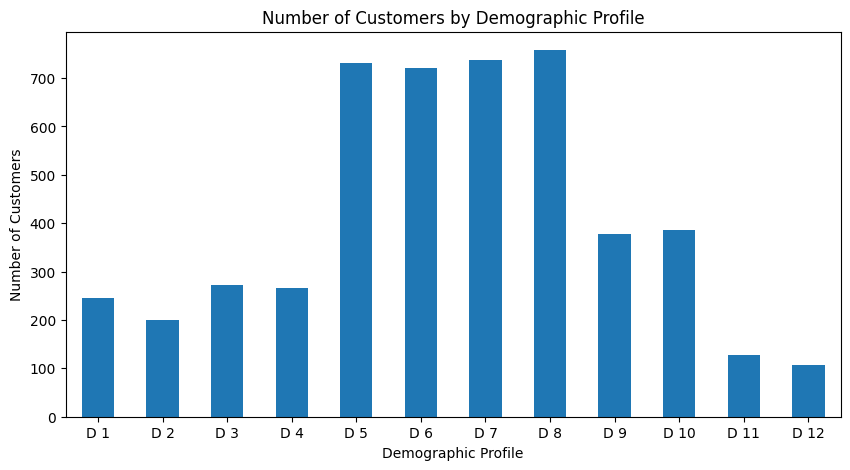

In [27]:
profile_counts = df.groupby("Demographic_Profile")["Customer_ID"].nunique()

profile_counts = profile_counts.reindex([
    "D 1", "D 2", "D 3", "D 4",
    "D 5", "D 6", "D 7", "D 8",
    "D 9", "D 10", "D 11", "D 12"
])

profile_counts.plot(
    kind="bar",
    figsize=(10, 5),
    title="Number of Customers by Demographic Profile"
)

plt.xlabel("Demographic Profile")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

Yuxarıda Demoqrafik Müştəri Profilini quruluşu göstərilmişdir.

---

### Demographic Profile Analysis -- Əsas Göstəricilər

In [28]:
top_3_customer_count = profile_counts.sort_values(ascending=False).head(3)

print(top_3_customer_count)

Demographic_Profile
D 8    758
D 7    738
D 5    731
Name: Customer_ID, dtype: int64


In [29]:
order_count = df.groupby("Demographic_Profile")["Order_ID"].nunique()

top_3_total_order_count = order_count.sort_values(ascending=False).head(3)

print(top_3_total_order_count)

Demographic_Profile
D 8    2573
D 5    2520
D 7    2514
Name: Order_ID, dtype: int64


In [30]:
customer_count = df.groupby("Demographic_Profile")["Customer_ID"].nunique()

order_count_per_customer = order_count / customer_count

top_3_order_count_per_customer = order_count_per_customer.sort_values(ascending=False).head(3)

print(top_3_order_count_per_customer)

Demographic_Profile
D 1    3.726531
D 9    3.555556
D 5    3.447332
dtype: float64


In [31]:
total_amount = df.groupby("Demographic_Profile")["Total_Amount"].sum()

top_3_total_amount = total_amount.sort_values(ascending=False).head(3)

print(top_3_total_amount)

Demographic_Profile
D 7    3431496.08
D 8    3196148.58
D 6    3156314.27
Name: Total_Amount, dtype: float64


In [32]:
customer_count = df.groupby("Demographic_Profile")["Customer_ID"].nunique()

average_amount_per_customer = total_amount / customer_count

top_3_average_amount_per_customer = (
    average_amount_per_customer
    .sort_values(ascending=False)
    .head(3)
)

print(top_3_average_amount_per_customer)

Demographic_Profile
D 3    4707.012463
D 7    4649.723686
D 2    4530.924874
dtype: float64


In [33]:
# Customer Count
top_3_customer_count = (
    profile_counts
    .sort_values(ascending=False)
    .head(3)
)

# Total Order Count
top_3_total_order_count = (
    order_count
    .sort_values(ascending=False)
    .head(3)
)

# Order Count per Customer
top_3_order_count_per_customer = (
    order_count_per_customer
    .sort_values(ascending=False)
    .head(3)
)

# Total Amount
top_3_total_amount = (
    total_amount
    .sort_values(ascending=False)
    .head(3)
)

# Average Amount per Customer
top_3_average_amount_per_customer = (
    average_amount_per_customer
    .sort_values(ascending=False)
    .head(3)
)


# Ulduzları toplamaq
star_score = {}

top_3_lists = [
    top_3_customer_count,
    top_3_total_order_count,
    top_3_order_count_per_customer,
    top_3_total_amount,
    top_3_average_amount_per_customer
]

for result in top_3_lists:
    for rank, profile in enumerate(result.index):
        stars = 3 - rank
        star_score[profile] = star_score.get(profile, 0) + stars

print(star_score)

{'D 8': 8, 'D 7': 8, 'D 5': 4, 'D 1': 3, 'D 9': 2, 'D 6': 1, 'D 3': 3, 'D 2': 1}


In [34]:
star_score_table = pd.DataFrame(
    list(star_score.items()),
    columns=["Demographic_Profile", "Economic_Score"]
)

star_score_table = star_score_table.sort_values(
    "Economic_Score",
    ascending=False
)

print(star_score_table.to_string(index=False))

Demographic_Profile  Economic_Score
                D 8               8
                D 7               8
                D 5               4
                D 1               3
                D 3               3
                D 9               2
                D 6               1
                D 2               1


### Demographic Profile Analysis

Müştərilər yaş qrupu və cinsə əsasən 12 demoqrafik profilə (`D 1` – `D 12`) bölündü. Hər profil üzrə müştəri sayı müəyyən edildi və satış göstəricilərinin müqayisəsi aparıldı.

Əsas göstəricilər:

* **Customer Count** – hər profildəki unikal müştəri sayı
* **Total Order Count** – hər profil üzrə ümumi unikal sifariş sayı
* **Order Count per Customer** – müştəri başına düşən orta sifariş sayı
* **Total Amount** – profilin yaratdığı ümumi satış məbləği
* **Average Amount per Customer** – müştəri başına düşən orta satış məbləği

Hər göstərici üzrə **Top 3 profil** müəyyən edildi. 1-ci yerə **3 ⭐**, 2-ci yerə **2 ⭐**, 3-cü yerə isə **1 ⭐** verildi. Daha sonra profillərin topladığı ulduzlar cəmlənərək onların ümumi iqtisadi göstəriciləri üzrə müqayisəsi aparıldı.

----


### 6. Demoqrafik MP-l' Product Category Preference

In [35]:
# Ən dəyərli 3 demoqrafik profil
top_profiles = (
    star_score_table
    .head(3)["Demographic_Profile"]
)

# Hər profil üçün Top 3 Product Category
top_categories = {}

for profile in top_profiles:
    category_counts = (
        df[df["Demographic_Profile"] == profile]
        ["Product_Category"]
        .value_counts()
        .head(3)
    )
    
    top_categories[profile] = category_counts.index.tolist()


# Nəticəni cədvələ çevirmək
product_category_table = pd.DataFrame(
    top_categories
).T

product_category_table.columns = [
    "Top 1 Product Category",
    "Top 2 Product Category",
    "Top 3 Product Category"
]

product_category_table.index.name = "Demographic Profile"

print(product_category_table)

                    Top 1 Product Category Top 2 Product Category  \
Demographic Profile                                                 
D 8                                 Beauty                  Books   
D 7                                 Sports                   Food   
D 5                                  Books                Fashion   

                    Top 3 Product Category  
Demographic Profile                         
D 8                                 Sports  
D 7                                 Beauty  
D 5                                   Toys  


Ən yüksək iqtisadi score əldə edən **3 demoqrafik profil** müəyyən edildi. Hər profil üçün ən çox seçilən **Top 3 Product Category** müəyyən edilərək müqayisə edildi.

**Məqsəd:** Ən dəyərli müştəri profillərinin hansı məhsul kateqoriyalarına üstünlük verdiyini müəyyənləşdirmək.

---

### Demoqrafiq MP -- Loyallıq 

In [36]:
# Hər müştərinin Demographic Profile-ını müəyyən edirik
customer_profiles = (
    df.groupby("Customer_ID")["Demographic_Profile"]
    .first()
)

# Hər loyalty qrupunu Demographic Profile ilə əlaqələndiririk
new_customers = customer_profiles.loc[only_false.index]
short_time_returning = customer_profiles.loc[false_to_true.index]
long_time_returning = customer_profiles.loc[only_true.index]


# Demographic Profile üzrə müştəri saylarını hesablayırıq
new_counts = new_customers.value_counts()
short_counts = short_time_returning.value_counts()
long_counts = long_time_returning.value_counts()


# Ümumi müştəri sayı
total_customers = customer_profiles.value_counts()


# Hər Demographic Profile daxilində faiz
new_percent = (new_counts / total_customers * 100).fillna(0)
short_percent = (short_counts / total_customers * 100).fillna(0)
long_percent = (long_counts / total_customers * 100).fillna(0)


# Nəticəni cədvəldə göstəririk
loyalty_by_demographic = pd.DataFrame({
    "New Customer": new_percent,
    "Short-Term Returning": short_percent,
    "Long-Term Returning": long_percent
}).fillna(0)

profile_order = [
    "D 1", "D 2", "D 3", "D 4",
    "D 5", "D 6", "D 7", "D 8",
    "D 9", "D 10", "D 11", "D 12"
]

loyalty_by_demographic = loyalty_by_demographic.reindex(profile_order)


print(loyalty_by_demographic)

                     New Customer  Short-Term Returning  Long-Term Returning
Demographic_Profile                                                         
D 1                      4.489796             36.734694            58.775510
D 2                      6.030151             37.688442            56.281407
D 3                      6.617647             27.573529            65.808824
D 4                      6.741573             34.456929            58.801498
D 5                      8.207934             34.062927            57.729138
D 6                      7.500000             33.611111            58.888889
D 7                      6.368564             33.875339            59.756098
D 8                      6.860158             32.453826            60.686016
D 9                      5.291005             33.597884            61.111111
D 10                     7.532468             30.909091            61.558442
D 11                     9.375000             28.906250            61.718750

Analizimizə görə aşağıdakılar müşahidə edilir:

* D 11 və D 12 profilləri müştəri nisbətində yeni müştərilərin daha çox olduğu profillərdir.
* D 1, D 2 profilləri isə qısa-dönəm qayıdan müştərilərin nisbətən daha çox olduğu profillərdir.
* Uzun-dönəm qayıdışlarında isə D 3 profilində açıq fərq müşahidə olunur.


---

## Behavioral Customer MP analizi

In [90]:
behavioral_data = (
    df.groupby("Customer_ID")
    .agg({
        "Pages_Viewed": "mean",
        "Session_Duration_Minutes": "mean",
        "Is_Returning_Customer": "sum",
        "Discount_Amount": "mean",
        "Total_Amount": "mean",
        "Quantity": "mean"
    })
    .reset_index()
)



In [93]:
# Discount Rate — customer level
discount_rate = (
    df.groupby("Customer_ID")["Discount_Amount"]
    .apply(lambda x: (x > 0).mean() * 100)
    .rename("Discount_Rate")
)

# Quantity — customer level
quantity_mean = (
    df.groupby("Customer_ID")["Quantity"]
    .mean()
    .rename("Quantity")
)

# behavioral_data-ya düzgün Customer_ID ilə birləşdir
behavioral_data = behavioral_data.drop(
    columns=["Discount_Rate", "Quantity"],
    errors="ignore"
)

behavioral_data = behavioral_data.merge(
    discount_rate,
    on="Customer_ID",
    how="left"
)

behavioral_data = behavioral_data.merge(
    quantity_mean,
    on="Customer_ID",
    how="left"
)

In [94]:
discount_rate = (
    df.groupby("Customer_ID")["Discount_Amount"]
    .apply(lambda x: (x > 0).mean() * 100)
)

behavioral_data["Discount_Rate"] = discount_rate

In [95]:
behavioral_data["Quantity"] = (
    df.groupby("Customer_ID")["Quantity"]
    .mean()
)

In [96]:
behavioral_data["Pages_Level"] = behavioral_data["Pages_Viewed"].apply(
    lambda x: "Low" if x <= 7 else "Mid" if x <= 10 else "High"
)

behavioral_data["Session_Level"] = behavioral_data["Session_Duration_Minutes"].apply(
    lambda x: "Low" if x <= 12 else "Mid" if x <= 16 else "High"
)

behavioral_data["Returning_Level"] = behavioral_data["Is_Returning_Customer"].apply(
    lambda x: "Low" if x == 0 else "Mid" if x <= 5 else "High"
)

behavioral_data["Discount_Level"] = behavioral_data["Discount_Rate"].apply(
    lambda x: "Low" if x == 0 else "Mid" if x <= 50 else "High"
)

behavioral_data["Quantity_Level"] = behavioral_data["Quantity"].apply(
    lambda x: "Mid" if x <= 4 else "High"
)

In [103]:
print(behavioral_data[
    [
        "Pages_Level",
        "Session_Level",
        "Returning_Level",
        "Discount_Level",
        "Quantity_Level"
    ]
].head(10))

  Pages_Level Session_Level Returning_Level Discount_Level Quantity_Level
0         Mid           Mid             Mid           High           High
1         Mid           Mid             Mid           High           High
2         Mid           Low             Mid           High           High
3        High           Mid             Low           High           High
4         Mid           Mid             Mid           High           High
5         Mid           Mid             Mid           High           High
6         Mid          High             Mid           High           High
7         Mid          High             Mid           High           High
8        High           Low             Low           High           High
9         Mid           Mid             Mid           High           High


In [104]:
print("Pages Viewed:")
print(behavioral_data["Pages_Level"].value_counts())

print("\nSession Duration:")
print(behavioral_data["Session_Level"].value_counts())

print("\nReturning Customer:")
print(behavioral_data["Returning_Level"].value_counts())

print("\nDiscount Rate:")
print(behavioral_data["Discount_Level"].value_counts())

print("\nQuantity:")
print(behavioral_data["Quantity_Level"].value_counts())

Pages Viewed:
Pages_Level
Mid     3549
High     921
Low      530
Name: count, dtype: int64

Session Duration:
Session_Level
Mid     3627
High     850
Low      523
Name: count, dtype: int64

Returning Customer:
Returning_Level
Mid     3932
High     719
Low      349
Name: count, dtype: int64

Discount Rate:
Discount_Level
High    5000
Name: count, dtype: int64

Quantity:
Quantity_Level
High    5000
Name: count, dtype: int64


In [105]:
print(behavioral_data["Discount_Level"].value_counts())
print("\nTotal:", behavioral_data["Discount_Level"].value_counts().sum())

Discount_Level
High    5000
Name: count, dtype: int64

Total: 5000


In [106]:
behavior_patterns = (
    behavioral_data[
        [
            "Pages_Level",
            "Session_Level",
            "Returning_Level",
            "Discount_Level",
            "Quantity_Level"
        ]
    ]
    .value_counts()
    .reset_index(name="Customer_Count")
)

print(behavior_patterns)

   Pages_Level Session_Level Returning_Level Discount_Level Quantity_Level  \
0          Mid           Mid             Mid           High           High   
1          Mid           Mid            High           High           High   
2         High           Mid             Mid           High           High   
3          Mid          High             Mid           High           High   
4          Low           Mid             Mid           High           High   
5          Mid           Low             Mid           High           High   
6         High          High             Mid           High           High   
7         High           Low             Mid           High           High   
8          Low          High             Mid           High           High   
9          Mid           Mid             Low           High           High   
10        High           Mid            High           High           High   
11         Low           Low             Mid           High     

In [107]:
print(behavior_patterns.head(30))

   Pages_Level Session_Level Returning_Level Discount_Level Quantity_Level  \
0          Mid           Mid             Mid           High           High   
1          Mid           Mid            High           High           High   
2         High           Mid             Mid           High           High   
3          Mid          High             Mid           High           High   
4          Low           Mid             Mid           High           High   
5          Mid           Low             Mid           High           High   
6         High          High             Mid           High           High   
7         High           Low             Mid           High           High   
8          Low          High             Mid           High           High   
9          Mid           Mid             Low           High           High   
10        High           Mid            High           High           High   
11         Low           Low             Mid           High     

In [108]:
print(behavioral_data["Discount_Rate"].describe())
print(behavioral_data["Discount_Level"].value_counts())

print(behavioral_data["Quantity"].describe())
print(behavioral_data["Quantity_Level"].value_counts())

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Discount_Rate, dtype: float64
Discount_Level
High    5000
Name: count, dtype: int64
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Quantity, dtype: float64
Quantity_Level
High    5000
Name: count, dtype: int64
